# Data Overview

In [1]:

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


Unique values in 'split' column: ['train' 'valid']
Total Samples: 59469
Training Samples: 59395
Validation Samples: 74
Total Samples: 59469
Training Samples: 59395
Validation Samples: 74


C:\Users\david\AppData\Local\Temp\ipykernel_21868\1404930333.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Split', y='Count', data=split_counts, palette=['#1f77b4', '#ff7f0e'])


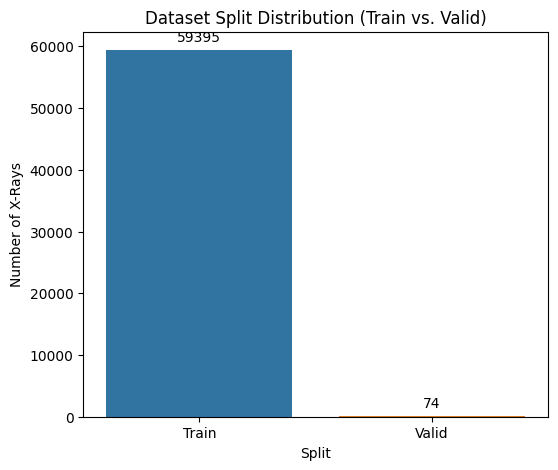

In [2]:
### Dataset Overview


# Total samples (train, val)


# train_df = pd.read_csv("../my_final_dataset.csv") 
# print( train_df.columns )

# # If you have a separate validation file (e.g. valid.csv from the original download)
# valid_df = pd.read_csv("../valid.csv") 
# print( valid_df.columns )
# OR if your main CSV has a 'split' column (CheXpert often does: 'train' vs 'valid')
df = pd.read_csv("../my_final_dataset.csv")
if 'split' in df.columns:
    # Get all unique values to see if there's hidden spaces like "valid "
    unique_splits = df['split'].unique()
    print(f"Unique values in 'split' column: {unique_splits}")
    
    # FIX: Strip whitespace just in case
    df['split'] = df['split'].astype(str).str.strip()
else:
    print("WARNING: 'split' column not found!")
    # Fallback: Create split column based on file path
    print("Creating 'split' column from image paths...")
    df['split'] = df['path_to_image'].apply(lambda x: 'valid' if 'valid/' in str(x) else 'train')

train_df = df[df['split'] == 'train']
valid_df = df[df['split'] == 'valid']

# 4. Recalculate Counts
n_train = len(train_df)
n_valid = len(valid_df)
n_total = len(df)

print(f"Total Samples: {n_total}")
print(f"Training Samples: {n_train}")
print(f"Validation Samples: {n_valid}")


# --- 2. Calculate Totals ---
n_train = len(train_df)
n_valid = len(valid_df)
n_total = n_train + n_valid

print(f"Total Samples: {n_total}")
print(f"Training Samples: {n_train}")
print(f"Validation Samples: {n_valid}")

# --- 3. Visualization ---
# Create a simple dataframe for plotting
split_counts = pd.DataFrame({
    'Split': ['Train', 'Valid'],
    'Count': [n_train, n_valid]
})

plt.figure(figsize=(6, 5))
ax = sns.barplot(x='Split', y='Count', data=split_counts, palette=['#1f77b4', '#ff7f0e'])

# Add the actual numbers on top of the bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points')

plt.title("Dataset Split Distribution (Train vs. Valid)")
plt.ylabel("Number of X-Rays")
plt.show()


Unique values in 'split' column: ['train' 'valid']

--- CORRECTED COUNTS ---
Total Samples: 59469
Training Samples: 59395
Validation Samples: 74


C:\Users\david\AppData\Local\Temp\ipykernel_2952\670465471.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Split', y='Count', data=split_counts, palette=['#1f77b4', '#ff7f0e'])


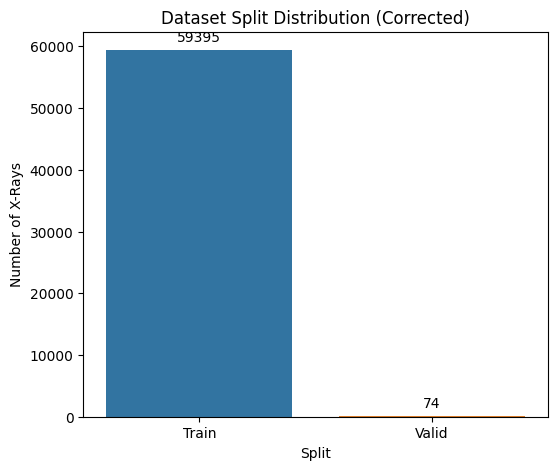

In [12]:

# 1. Load the dataset
df = pd.read_csv("../my_final_dataset.csv")


if 'split' in df.columns:
    # Get all unique values to see if there's hidden spaces like "valid "
    unique_splits = df['split'].unique()
    print(f"Unique values in 'split' column: {unique_splits}")
    
    # FIX: Strip whitespace just in case
    df['split'] = df['split'].astype(str).str.strip()
else:
    print("WARNING: 'split' column not found!")
    # Fallback: Create split column based on file path
    print("Creating 'split' column from image paths...")
    df['split'] = df['path_to_image'].apply(lambda x: 'valid' if 'valid/' in str(x) else 'train')

# 3. Separate Dataframes safely
train_df = df[df['split'] == 'train']
valid_df = df[df['split'] == 'valid']

# 4. Recalculate Counts
n_train = len(train_df)
n_valid = len(valid_df)
n_total = len(df)

print("\n--- CORRECTED COUNTS ---")
print(f"Total Samples: {n_total}")
print(f"Training Samples: {n_train}")
print(f"Validation Samples: {n_valid}")

# 5. Visualization
if n_valid > 0:
    split_counts = pd.DataFrame({
        'Split': ['Train', 'Valid'],
        'Count': [n_train, n_valid]
    })

    plt.figure(figsize=(6, 5))
    ax = sns.barplot(x='Split', y='Count', data=split_counts, palette=['#1f77b4', '#ff7f0e'])
    
    # Add numbers on bars
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha = 'center', va = 'center', 
                    xytext = (0, 9), 
                    textcoords = 'offset points')

    plt.title("Dataset Split Distribution (Corrected)")
    plt.ylabel("Number of X-Rays")
    plt.show()
else:
    print("Let's look at the first 5 image paths to see if they contain 'valid/':")
    print(df['path_to_image'].head().values)

<Figure size 1800x800 with 0 Axes>

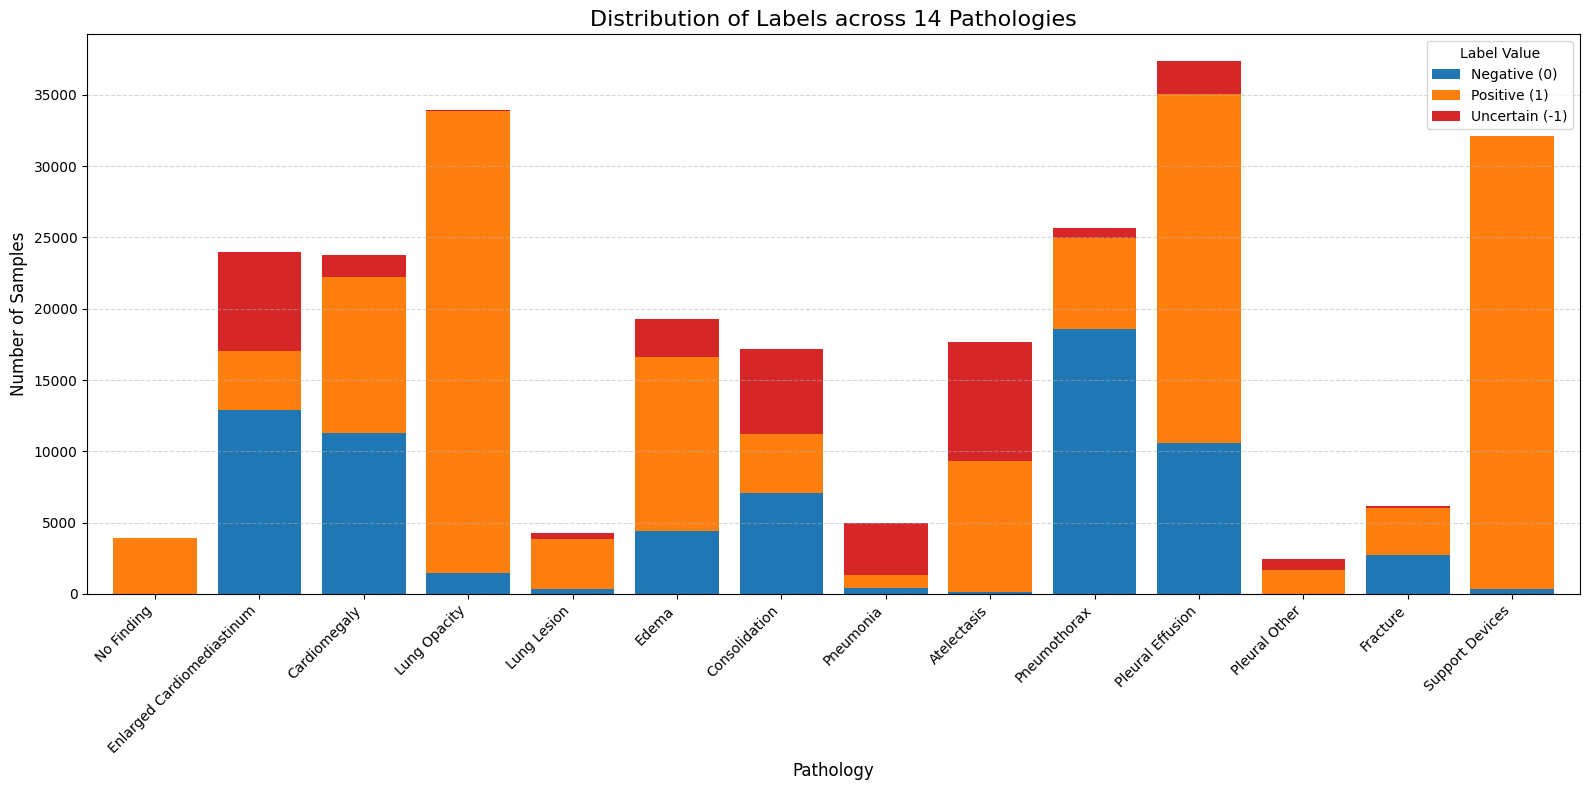


--- Detailed Stats (for your Thesis Table) ---
                            Negative (0)  Positive (1)  Uncertain (-1)
No Finding                             0          3940               0
Enlarged Cardiomediastinum         12928          4130            6909
Cardiomegaly                       11261         10971            1554
Lung Opacity                        1488         32358             105
Lung Lesion                          329          3490             459
Edema                               4443         12148            2687
Consolidation                       7083          4159            5938
Pneumonia                            381           915            3702
Atelectasis                          167          9136            8371
Pneumothorax                       18577          6391             702
Pleural Effusion                   10586         24511            2281
Pleural Other                         13          1663             759
Fracture                     

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load Data
df = pd.read_csv("../my_final_dataset.csv")

# 2. Define the 14 Pathologies
labels = [
    'No Finding', 'Enlarged Cardiomediastinum', 'Cardiomegaly', 'Lung Opacity', 
    'Lung Lesion', 'Edema', 'Consolidation', 'Pneumonia', 'Atelectasis', 
    'Pneumothorax', 'Pleural Effusion', 'Pleural Other', 'Fracture', 'Support Devices'
]

# 3. Calculate Counts for 0.0, 1.0, and -1.0
counts_dict = {}

for label in labels:
    # Get value counts (handle NaNs by filling with 0 temporarily for counting if needed, 
    # but usually we just dropna or ignore them)
    val_counts = df[label].value_counts()
    
    # Store in dictionary: 0 (Negative), 1 (Positive), -1 (Uncertain)
    # We use .get() to return 0 if that label value doesn't exist for a disease
    counts_dict[label] = {
        'Negative (0)': val_counts.get(0.0, 0),
        'Positive (1)': val_counts.get(1.0, 0),
        'Uncertain (-1)': val_counts.get(-1.0, 0)
    }

# 4. Convert to DataFrame for easy plotting
counts_df = pd.DataFrame(counts_dict).transpose()

# 5. Plot
plt.figure(figsize=(18, 8))
# Stacked bar chart
counts_df.plot(kind='bar', stacked=True, 
              color=['#1f77b4', '#ff7f0e', '#d62728'], # Blue, Orange, Red
              figsize=(16, 8), width=0.8)

plt.title("Distribution of Labels across 14 Pathologies", fontsize=16)
plt.ylabel("Number of Samples", fontsize=12)
plt.xlabel("Pathology", fontsize=12)
plt.legend(title="Label Value", loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 6. Print specific stats for your thesis text
print("\n--- Detailed Stats (for your Thesis Table) ---")
print(counts_df)

Total Images:   59469
Unique Patients: 27375
Avg Images/Patient: 2.17

--- Images per Patient Statistics ---
count    27375.000000
mean         2.172384
std          2.088401
min          1.000000
25%          1.000000
50%          2.000000
75%          2.000000
max         47.000000
Name: count, dtype: float64


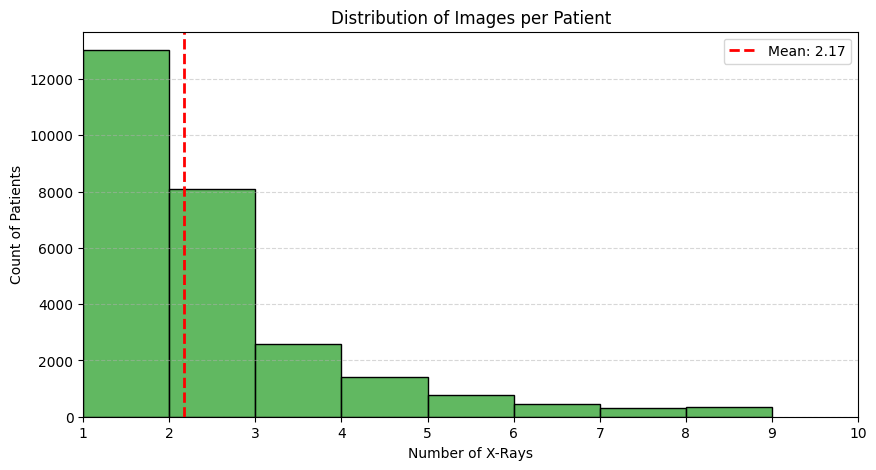


--- Top 5 Patients with the most images ---
deid_patient_id
patient14351    47
patient19968    36
patient29732    35
patient07084    33
patient01221    31
Name: count, dtype: int64


In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load Data
df = pd.read_csv("../my_final_dataset.csv")

# 2. Identify Patient ID
# Your CSV should have 'deid_patient_id'. If not, we extract it from the image path.
if 'deid_patient_id' in df.columns:
    patient_col = 'deid_patient_id'
else:
    # Fallback: Extract 'patientXXXXX' from 'train/patientXXXXX/study...'
    print("Extracting patient IDs from file paths...")
    df['patient_id_temp'] = df['path_to_image'].apply(lambda x: x.split('/')[1])
    patient_col = 'patient_id_temp'

# 3. Calculate Key Metrics
num_unique_patients = df[patient_col].nunique()
total_images = len(df)
avg_images = total_images / num_unique_patients

print(f"Total Images:   {total_images}")
print(f"Unique Patients: {num_unique_patients}")
print(f"Avg Images/Patient: {avg_images:.2f}")

# 4. Analyze Distribution (Images per Patient)
# Count how many images each patient has
patient_counts = df[patient_col].value_counts()

print("\n--- Images per Patient Statistics ---")
print(patient_counts.describe()) 

# 5. Visualization: Histogram
plt.figure(figsize=(10, 5))
sns.histplot(patient_counts, bins=range(1, 10), kde=False, color='#2ca02c')
plt.title("Distribution of Images per Patient")
plt.xlabel("Number of X-Rays")
plt.ylabel("Count of Patients")
plt.xlim(1, 10) # Most patients have 1-3 images, limiting x-axis makes it readable
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Add a vertical line for the mean
plt.axvline(patient_counts.mean(), color='red', linestyle='--', linewidth=2, 
            label=f'Mean: {patient_counts.mean():.2f}')
plt.legend()
plt.show()

# 6. Check for "Super Users" (Outliers)
print("\n--- Top 5 Patients with the most images ---")
print(patient_counts.head(5))

Extracting Study IDs from paths...

--- A. Studies per Patient ---
Max studies for one patient: 38
Avg studies per patient: 1.76

--- B. Images per Study ---
Avg images per study: 1.23
Most common study sizes:
1    37537
2     9970
3      664
Name: count, dtype: int64


C:\Users\david\AppData\Local\Temp\ipykernel_2952\2189370980.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=images_per_study, ax=axes[1], palette='viridis')


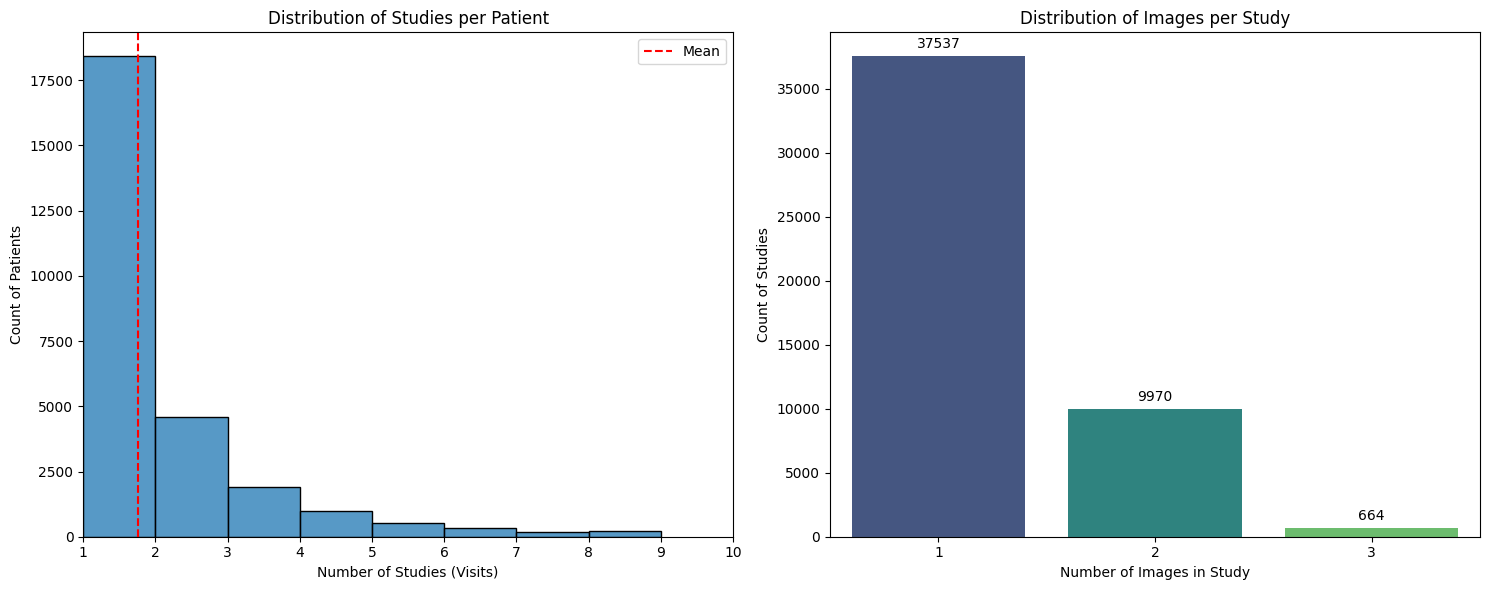

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load Data
df = pd.read_csv("../my_final_dataset.csv")

# 2. Extract Patient and Study Information from Path
# Assuming path format: "train/patient00001/study1/view1_frontal.jpg"
# We split by '/' to get the components
def extract_metadata(path):
    parts = path.split('/')
    # parts[1] is 'patientXXXXX', parts[2] is 'studyX'
    return pd.Series([parts[1], parts[2]])

# Apply extraction
print("Extracting Study IDs from paths...")
df[['patient_id', 'study_id']] = df['path_to_image'].apply(extract_metadata)

# 3. ANALYSIS A: How many Studies per Patient? (Longitudinal)
# Group by patient and count unique study IDs
studies_per_patient = df.groupby('patient_id')['study_id'].nunique()

print("\n--- A. Studies per Patient ---")
print(f"Max studies for one patient: {studies_per_patient.max()}")
print(f"Avg studies per patient: {studies_per_patient.mean():.2f}")

# 4. ANALYSIS B: How many Images per Study? (Multi-view)
# Group by (Patient + Study) and count rows (images)
images_per_study = df.groupby(['patient_id', 'study_id']).size()

print("\n--- B. Images per Study ---")
print(f"Avg images per study: {images_per_study.mean():.2f}")
print("Most common study sizes:")
print(images_per_study.value_counts().head())

# 5. Visualizations
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot A: Studies per Patient
sns.histplot(studies_per_patient, bins=range(1, 10), kde=False, ax=axes[0], color='#1f77b4')
axes[0].set_title("Distribution of Studies per Patient")
axes[0].set_xlabel("Number of Studies (Visits)")
axes[0].set_ylabel("Count of Patients")
axes[0].set_xlim(1, 10) # Limit x-axis to zoom in on the majority
axes[0].axvline(studies_per_patient.mean(), color='red', linestyle='--', label='Mean')
axes[0].legend()

# Plot B: Images per Study
# We use a bar chart because this is usually discrete (1, 2, or 3 images)
sns.countplot(x=images_per_study, ax=axes[1], palette='viridis')
axes[1].set_title("Distribution of Images per Study")
axes[1].set_xlabel("Number of Images in Study")
axes[1].set_ylabel("Count of Studies")

# Add numbers on top of bars for Plot B
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height())}', 
                     (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha='center', va='center', xytext=(0, 9), textcoords='offset points')

plt.tight_layout()
plt.show()

--- View Counts ---
frontal_lateral
Frontal    49663
Lateral     9806
Name: count, dtype: int64

--- Projection Counts (Frontal Only) ---
ap_pa
AP    40611
PA     9045
LL        6
RL        1
Name: count, dtype: int64


C:\Users\david\AppData\Local\Temp\ipykernel_2952\1809046141.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=view_counts.index, y=view_counts.values, ax=axes[0], palette="Blues_d")


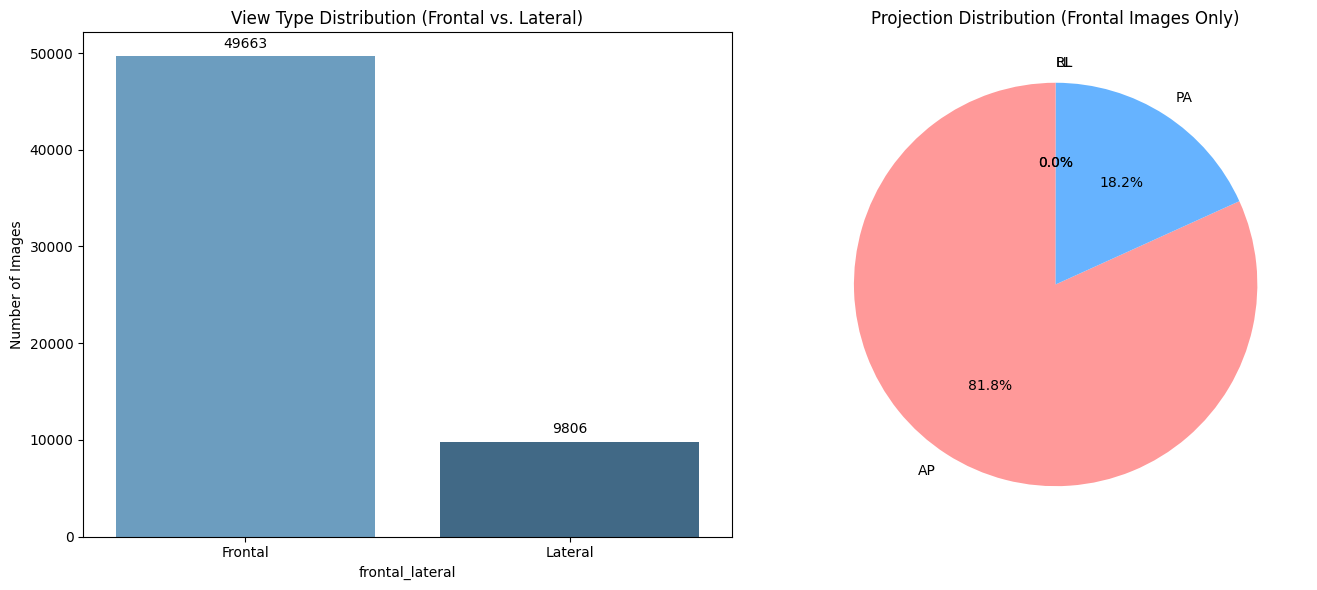


--- Bias Check: Cardiomegaly Rate by View ---
Cardiomegaly Rate in AP (Portable): 60.88%
Cardiomegaly Rate in PA (Standard): 38.41%
>> Insight: AP views have a higher rate of Cardiomegaly labels.
   (Reason: AP magnification makes the heart look bigger + AP patients are sicker.)


In [18]:

df = pd.read_csv("../my_final_dataset.csv")

# 2. Check for relevant columns
# CheXpert usually has 'frontal_lateral' and 'ap_pa'
if 'frontal_lateral' not in df.columns or 'ap_pa' not in df.columns:
    print("Columns 'frontal_lateral' or 'ap_pa' not found.")
    print("Available columns:", df.columns.tolist())
else:
    # --- ANALYSIS 1: Frontal vs. Lateral ---
    view_counts = df['frontal_lateral'].value_counts()
    
    # --- ANALYSIS 2: AP vs. PA (Frontal Only) ---
    # AP/PA usually only applies to Frontal images. Lateral images often have NaN in 'ap_pa'.
    frontal_df = df[df['frontal_lateral'] == 'Frontal']
    projection_counts = frontal_df['ap_pa'].value_counts()

    print("--- View Counts ---")
    print(view_counts)
    print("\n--- Projection Counts (Frontal Only) ---")
    print(projection_counts)

    # --- VISUALIZATION ---
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Plot A: Frontal vs Lateral
    sns.barplot(x=view_counts.index, y=view_counts.values, ax=axes[0], palette="Blues_d")
    axes[0].set_title("View Type Distribution (Frontal vs. Lateral)")
    axes[0].set_ylabel("Number of Images")
    
    # Add numbers on top
    for p in axes[0].patches:
        axes[0].annotate(f'{int(p.get_height())}', 
                         (p.get_x() + p.get_width() / 2., p.get_height()), 
                         ha='center', va='center', xytext=(0, 9), textcoords='offset points')

    # Plot B: AP vs PA (The "Bias" Check)
    # We use a Pie Chart here to show the proportion clearly
    axes[1].pie(projection_counts, labels=projection_counts.index, autopct='%1.1f%%', 
                colors=['#ff9999', '#66b3ff'], startangle=90)
    axes[1].set_title("Projection Distribution (Frontal Images Only)")

    plt.tight_layout()
    plt.show()

    # --- ANALYSIS 3: Why this matters (Bias Check) ---
    # Check if 'Cardiomegaly' is more common in AP views (it should be, partly due to magnification)
    if 'Cardiomegaly' in df.columns:
        print("\n--- Bias Check: Cardiomegaly Rate by View ---")
        ap_rate = frontal_df[frontal_df['ap_pa'] == 'AP']['Cardiomegaly'].replace(-1, 1).mean()
        pa_rate = frontal_df[frontal_df['ap_pa'] == 'PA']['Cardiomegaly'].replace(-1, 1).mean()
        
        print(f"Cardiomegaly Rate in AP (Portable): {ap_rate:.2%}")
        print(f"Cardiomegaly Rate in PA (Standard): {pa_rate:.2%}")
        
        if ap_rate > pa_rate:
            print(">> Insight: AP views have a higher rate of Cardiomegaly labels.")
            print("   (Reason: AP magnification makes the heart look bigger + AP patients are sicker.)")